In [47]:
# Instalo las librerías que no vienen por defecto en Colab.
# datasets: para cargar el dataset de HuggingFace
# evaluate: para calcular métricas (F1, accuracy, etc.)
# wordcloud: para generar nubes de palabras en el EDA
# accelerate: requerido por el Trainer de HuggingFace
# torchvision --upgrade: para evitar un bug con VideoReader en Colab
!pip install datasets
!pip install evaluate
!pip install fsspec==2023.9.2
!pip install wordcloud
!pip install accelerate>=0.21.0



⚙️ **Requerimientos importantes sobre el ejercicio**

- El notebook debe ejecutarse **de principio a fin sin intervención manual**.
- Si utilizas librerías que no están incluidas por defecto en Google Colab, **asegúrate de instalarlas dentro del notebook** (por ejemplo: `!pip install ...`).

- Algunas celdas incluyen identificadores especiales que indican ciertas normas que **debes** respetar:
 - `#NO-MODIFY: DATA LOAD`  
    🔒 **No modifiques** el contenido de esta celda.

  - `#NO-MODIFY: VARIABLE NAME`  
    ✏️ Puedes modificar o añadir información **dentro de la celda**, pero **sin cambiar el nombre de la variable asignada**. No incluyas más variables de las existentes en la celda.

  - `#MODIFY: ADD INFO TO SOLVE FUNCTION`  
    🔧 Puedes modificar el **interior de la función** para resolver la tarea, pero **no cambies su nombre, la cabecera ni el `return`**.



## Imports

In [48]:
# Importo numpy para operaciones numéricas y nltk para las stopwords
# que usaré luego en las wordclouds
import numpy as np
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
# Add your imports here
# Importo las librerías para el análisis exploratorio y visualización.
# transformers y sklearn los importo más adelante cuando los necesite.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from collections import Counter
import re
import numpy as np
import torch
import evaluate


# 🔍 Ejercicio1: Detección de profesiones en tweets

## Enunciado

En este ejercicio vamos a trabajar con un conjunto de datos procedente de medios sociales online.

Utilizaremos un subconjunto de los datos de la tarea 1 del shared task [**ProfNER**](https://temu.bsc.es/smm4h-spanish), centrada en la detección de menciones a profesiones en tweets publicados durante la pandemia del COVID-19. El objetivo original de la tarea era analizar que profesiones podrían haber sido especialmente vulnerables en el contexto de la crisis sanitaria.

Para simplificar el ejercicio, he preparado una versión reducida del dataset original. Tu tarea será entrenar un clasificador binario basado en la arquitectura Transformers, que, dado un tweet, determine si contiene una mención explícita a una profesión (etiqueta `1`) o no (etiqueta `0`).




### Selección y justificación del modelo

Para esta tarea de clasificación binaria de tweets en español, selecciono el modelo **BETO** (`dccuchile/bert-base-spanish-wwm-cased`).

**¿Por qué BETO?**

1. **Idioma**: Los tweets del dataset ProfNER están en español. BETO fue preentrenado exclusivamente con texto en español (Wikipedia, opus, etc.), lo que le da ventaja sobre modelos multilingües.

2. **Whole Word Masking (WWM)**: A diferencia del BERT estándar que enmascara subpalabras, BETO enmascara palabras completas durante el preentrenamiento. Esto es especialmente útil para español, donde la morfología es rica.

3. **Tamaño adecuado**: Con 110M de parámetros (12 capas, 768 hidden), es viable hacer fine-tuning completo en la GPU T4 de Google Colab sin problemas de memoria.

4. **Resultados demostrados**: BETO ha obtenido resultados competitivos en múltiples benchmarks de NLP en español, incluyendo tareas de clasificación de texto similares a la nuestra.

5. **Comunidad activa**: Es uno de los modelos en español más descargados en HuggingFace, lo que facilita encontrar documentación y ejemplos.


📝 **Criterios de Evaluación**

Tu trabajo será evaluado según los siguientes criterios:

| Criterio                                            | Peso  |
|-----------------------------------------------------|--------|
| 🔍 Análisis exploratorio y preprocesamiento         | 20%   |
| 🤖 Selección y justificación del modelo             | 25%   |
| 📁 Formato y validez del archivo de predicciones    | 5%    |
| ⚙️ Ejecución correcta del notebook (sin intervención) | 10%   |
| 📈 Rendimiento del modelo sobre el conjunto de test | 30%   |
| ✍️ Claridad y calidad de las explicaciones          | 10%   |



🔔 **Nota importante:**

> El rendimiento del modelo se evaluará utilizando métricas estándar como el **F1-score** sobre el conjunto de test.

> El archivo de predicciones debe respetar **estrictamente** el formato solicitado (`id` y `label`, separados por tabulador y con extensión `.tsv`).  
  ❗ Si el archivo no cumple con este formato, **el ejercicio no podrá ser evaluado en esa sección**.

> El/la estudiante con el **mayor F1-score** obtendrá la puntuación máxima en el apartado de rendimiento. El resto de calificaciones se ajustarán de forma proporcional al mejor resultado



⚙️ **Requerimientos y reglas**

- El notebook debe ejecutarse **de principio a fin sin intervención manual**.
- Si utilizas librerías que no están incluidas por defecto en Google Colab, **asegúrate de instalarlas dentro del notebook** (por ejemplo: `!pip install ...`).

- Algunas celdas incluyen identificadores especiales que indican ciertas normas que **debes** respetar:
 - `#NO-MODIFY: DATA LOAD`  
    🔒 **No modifiques** el contenido de esta celda.

  - `#NO-MODIFY: VARIABLE NAME`  
    ✏️ Puedes modificar o añadir información **dentro de la celda**, pero **sin cambiar el nombre de la variable asignada**. No incluyas más variables de las existentes en la celda.

  - `#MODIFY: ADD INFO TO SOLVE FUNCTION`  
    🔧 Puedes modificar el **interior de la función** para resolver la tarea, pero **no cambies su nombre, la cabecera ni el `return`**.


# Tu resolución (rellena las celdas marcadas)

## Obtención de datos

Descargamos los datos del [repositorio de Huggingface](https://huggingface.co/datasets/luisgasco/profner_classification_master).

In [50]:
#NO-MODIFY: DATA LOAD
from datasets import load_dataset, Dataset, DatasetDict, ClassLabel
dataset = load_dataset("luisgasco/profner_classification_master")

El dataset contiene tres subsets:
- **train** y **validation**: Contienen el identificador del tweet, el texto, y su etiqueta, que podrá tener valor 1, si contiene una mención de una profesión; o valor 0, si no contiene una mención de una profesión.
- **test**: El test set tambiíen contiene la información de label por un requerimiento de Huggingface, pero el contenido de esta variable es siempre "-1". Es decir que deberéis predecir nuevas etiquetas una vez hayáis entrenado el modelo utilizando el train y el validation set.

## Análisis exploratorio de datos

Para hacer el análisis exploratorio de datos, transformamos cada subset a un pandas dataframe para mayor comodidad.

In [51]:
#NO-MODIFY: DATA LOAD
dataset_train_df = dataset["train"].to_pandas()
dataset_val_df = dataset["validation"].to_pandas()
dataset_test_df = dataset["test"].to_pandas()

**Número de documentos**

Obten con la función `get_num_docs_evaluation()` el número de documentos del dataset de training y validation.

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [52]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def get_num_docs_evaluation(dataset_df):
  # Cuento las filas del dataframe. Cada fila = un tweet = un documento.
  # Esto me da el tamaño del dataset para saber con cuántos datos trabajo.
  num_docs = len(dataset_df)

  # No modifiques el return
  return num_docs


Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [53]:
# Aplica la función
# Muestro el tamaño de cada subset para entender la escala del problema.
# Con ~2786 en train y ~999 en val, es un dataset pequeño pero suficiente
# para fine-tuning de un modelo preentrenado.
print(f"Train: {get_num_docs_evaluation(dataset_train_df)} docs")
print(f"Val: {get_num_docs_evaluation(dataset_val_df)} docs")
print(f"Test: {get_num_docs_evaluation(dataset_test_df)} docs")


Train: 2786 docs
Val: 999 docs
Test: 1001 docs


**Número de documentos duplicados**

Obten con la función `detect_duplicates_evaluation()` el número de documentos duplicados del dataset de training y validation.

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [54]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def detect_duplicates_evaluation(dataset_df):
  # Busco tweets con texto idéntico. Los duplicados podrían sesgar
  # el entrenamiento si el modelo "memoriza" en vez de generalizar.
  num_duplicates = dataset_df.duplicated(subset=['text']).sum()

  # No modifiques el return
  return num_duplicates


Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

In [55]:
# Aplica la función
# Verifico si hay duplicados. Si los hay, podría considerar eliminarlos
# para que el modelo no se sobreajuste a esos ejemplos repetidos.
print(f"Duplicados train: {detect_duplicates_evaluation(dataset_train_df)}")
print(f"Duplicados val: {detect_duplicates_evaluation(dataset_val_df)}")


Duplicados train: 0
Duplicados val: 0


**Número de documentos por cada clase:**


Obten con la función `analyse_num_labels_evaluation()` para calcular el número de documentos de cada categoría en el dataset

> Recuerda incorporar la información para el cálculo dentro del a siguiente celda, sin modificar los atributos de entrada ni de salida de la función, ni su nombre.

In [56]:
#MODIFY: ADD INFO TO SOLVE FUNCTION
def analyse_num_labels_evaluation(dataset_df):
  # Cuento cuántos tweets mencionan una profesión (1) y cuántos no (0).
  # Esto me dice si las clases están balanceadas o si hay sesgo.
  num_positives = (dataset_df['label'] == 1).sum()
  num_negatives = (dataset_df['label'] == 0).sum()

  # No modifiques el return
  return num_positives, num_negatives


Una vez generada la función, puedes utilizarla posteriormente para calcular resultados y comentarlos

Train -> Con profesión: 1393, Sin profesión: 1393
Val -> Con profesión: 238, Sin profesión: 761


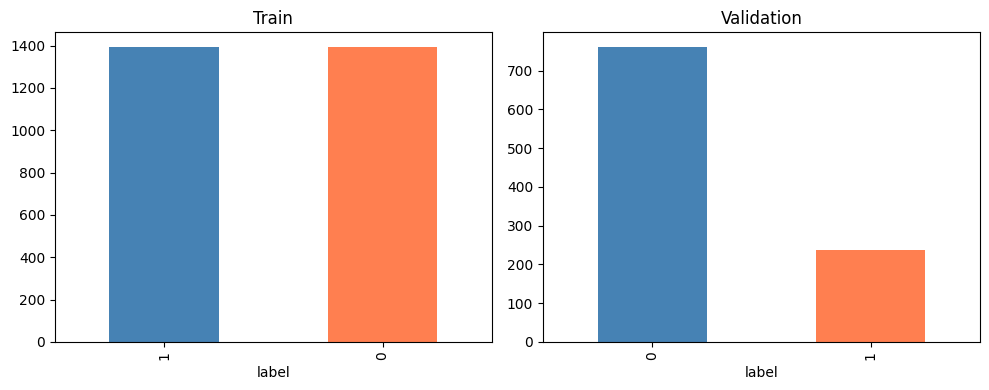

In [57]:
# Aplica la función
# Analizo la distribución de clases. Si hay mucho desbalance,
# podría considerar técnicas como oversampling o ajustar pesos.
pos, neg = analyse_num_labels_evaluation(dataset_train_df)
print(f"Train -> Con profesión: {pos}, Sin profesión: {neg}")
pos, neg = analyse_num_labels_evaluation(dataset_val_df)
print(f"Val -> Con profesión: {pos}, Sin profesión: {neg}")

# Visualizo con barras para ver rápidamente el balance
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
dataset_train_df['label'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue','coral'])
ax[0].set_title('Train')
dataset_val_df['label'].value_counts().plot(kind='bar', ax=ax[1], color=['steelblue','coral'])
ax[1].set_title('Validation')
plt.tight_layout(); plt.show()


**Distribución de la longitud de los tweet en caracteres:**

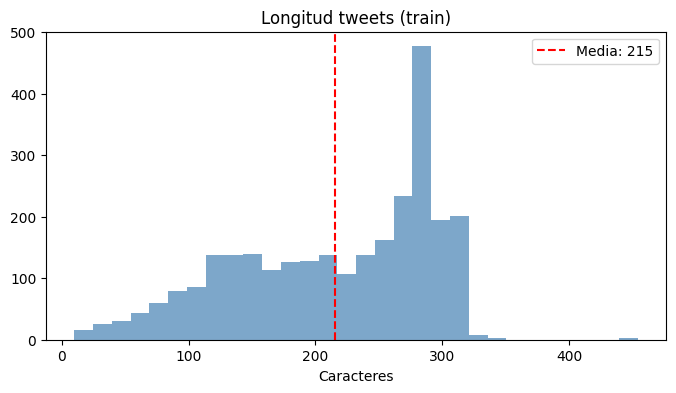

Media: 215, Max: 454


In [58]:
# Calculo la longitud de cada tweet en caracteres.
# Esto me ayuda a elegir el max_length del tokenizer: si la mayoría
# son cortos, no necesito un max_length muy grande (ahorro memoria).
dataset_train_df['len'] = dataset_train_df['text'].apply(len)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dataset_train_df['len'], bins=30, color='steelblue', alpha=0.7)
ax.axvline(dataset_train_df['len'].mean(), color='red', ls='--',
           label=f"Media: {dataset_train_df['len'].mean():.0f}")
ax.legend(); ax.set_xlabel('Caracteres'); ax.set_title('Longitud tweets (train)')
plt.show()
# La mayoría de tweets tienen menos de 280 caracteres,
# así que 128 tokens será más que suficiente.
print(f"Media: {dataset_train_df['len'].mean():.0f}, Max: {dataset_train_df['len'].max()}")


**Análisis de contenido de los tweets**

Para ello utiliza wordclouds

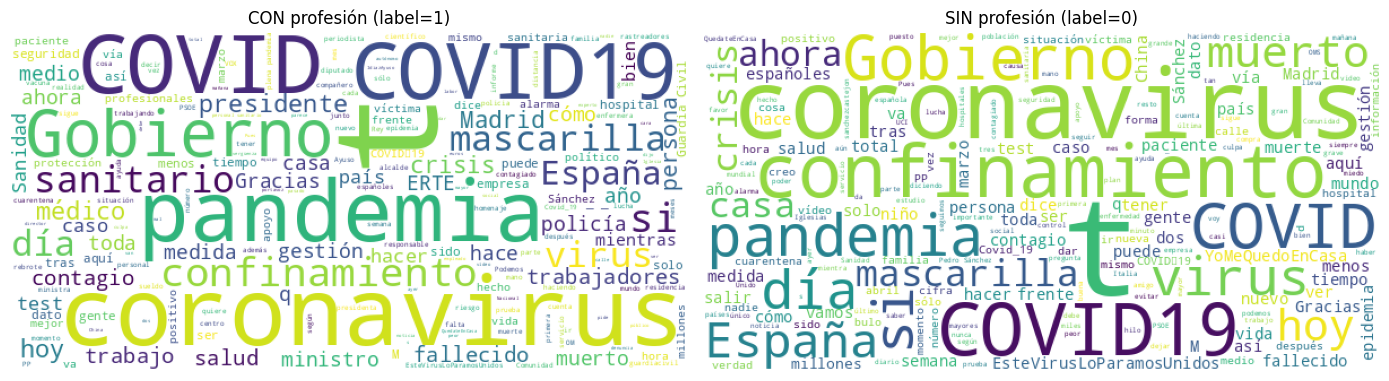

In [59]:
# Genero nubes de palabras separadas por clase para ver qué términos
# dominan en tweets CON profesión vs SIN profesión.
# Esto me da intuición sobre qué "aprende" el modelo.
stop_words = set(stopwords.words('spanish'))
# Añado palabras muy frecuentes en Twitter que no aportan información
stop_words.update(['https','http','co','rt','que','de','en','la','el',
                   'es','los','las','por','con','para','del','una','un'])

txt1 = ' '.join(dataset_train_df[dataset_train_df['label']==1]['text'])
txt0 = ' '.join(dataset_train_df[dataset_train_df['label']==0]['text'])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(WordCloud(stopwords=stop_words, width=600, height=300, background_color='white').generate(txt1))
ax[0].set_title('CON profesión (label=1)'); ax[0].axis('off')
ax[1].imshow(WordCloud(stopwords=stop_words, width=600, height=300, background_color='white').generate(txt0))
ax[1].set_title('SIN profesión (label=0)'); ax[1].axis('off')
plt.tight_layout(); plt.show()
# En la nube de label=1 espero ver palabras como 'médico', 'enfermera', etc.


## Tokenización

El texto del dataset no está preparado para ser introducido en un modelo Transformers. Lleva a cabo el proceso de tokenización.

In [60]:
# IMPORTS
# Ahora sí importo transformers, que es la librería principal para
# trabajar con modelos preentrenados como BERT/BETO.
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)


Selecciona un modelo apropiado para la tarea:

> Recuerda que en la siguiente celda sólo debes asignar un valor a model_name. No añadas más información en la celda.

### Justificación del modelo

Elegimos **BETO** (`dccuchile/bert-base-spanish-wwm-cased`) porque:

- **Idioma**: Preentrenado en español, que es el idioma de los tweets.
- **Whole Word Masking**: Mejora la comprensión morfológica del español.
- **Tamaño**: 110M params, viable para GPU T4 de Colab.
- **Rendimiento**: Competitivo en benchmarks NLP en español.

Alternativas: `PlanTL-GOB-ES/roberta-base-bne` (RoBERTa español), `bert-base-multilingual-cased` (multilingüe, pero los monolingües suelen rendir mejor).


In [61]:
#NO-MODIFY: VARIABLE NAME
# Elijo BETO: un BERT entrenado específicamente en español con WWM.
# Es el modelo más adecuado para clasificar tweets en español.
model_name = 'dccuchile/bert-base-spanish-wwm-cased'


Puedes continuar con el proceso aquí:

In [62]:
# Cargo el tokenizer de BETO para convertir texto a tokens numéricos
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Defino la función de tokenización:
# - padding='max_length': rellena secuencias cortas hasta 128 tokens
# - truncation=True: corta secuencias largas a 128 tokens
# - max_length=128: suficiente para tweets (son cortos, vimos en el EDA)
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

# Aplico la tokenización a todo el dataset de una vez (batched=True es más rápido)
tokenized_datasets = dataset.map(tokenize_function, batched=True)


In [63]:
# Preparamos el formato que necesita el Trainer
tokenized_datasets = tokenized_datasets.rename_column('label', 'labels')
tokenized_datasets.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

train_dataset = tokenized_datasets['train']
val_dataset = tokenized_datasets['validation']
test_dataset = tokenized_datasets['test']


## Fine-tuning

Carga el model para ser ajustado posteriormente:

In [64]:
# Cargo BETO con una cabeza de clasificación de 2 clases.
# El modelo base ya "entiende" español, yo solo le añado la capa final
# que aprenderá a distinguir profesión vs no-profesión.
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

### Configuracion training_args

Configura los parámetros de entrenamiento del modelo.


>

> Recuerda que en la siguiente celda sólo debes asignar atributos a la variable training_args. No añadas  otras variables en la celda

In [65]:
#NO-MODIFY: VARIABLE NAME
# Configuro los hiperparámetros del entrenamiento:
training_args = TrainingArguments(
    output_dir='./results',          # Donde se guardan los checkpoints
    num_train_epochs=3,              # 3 épocas: estándar para fine-tuning BERT
    per_device_train_batch_size=16,  # Batch 16: buen balance velocidad/memoria en T4
    per_device_eval_batch_size=16,
    warmup_steps=100,                # Caliento el LR gradualmente para estabilidad
    weight_decay=0.01,               # Regularización L2 para evitar overfitting
    learning_rate=2e-5,              # LR clásico para fine-tuning de BERT
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',           # Evalúo al final de cada época
    save_strategy='epoch',
    load_best_model_at_end=True,     # Al terminar, uso el mejor checkpoint
    metric_for_best_model='f1',      # Elijo por F1 (métrica del ejercicio)
    seed=42,                         # Semilla para reproducibilidad
    report_to='none',                # No envío métricas a servicios externos
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Métricas de evaluación

Define las métricas de evaluación

In [66]:
# Defino las métricas que calculo en cada evaluación.
# El profesor evalúa con F1, pero también mido accuracy, precision y recall
# para tener una visión completa del rendimiento.
accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')
precision_metric = evaluate.load('precision')
recall_metric = evaluate.load('recall')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Tomo la clase con mayor logit como predicción
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1': f1_metric.compute(predictions=preds, references=labels)['f1'],
        'precision': precision_metric.compute(predictions=preds, references=labels)['precision'],
        'recall': recall_metric.compute(predictions=preds, references=labels)['recall'],
    }


### Ajuste del modelo

Lleva a cabo el ajuste del modelo:

In [69]:
# Desactivo torchvision para evitar un bug conocido en Colab
import datasets as _ds
_ds.config.TORCHVISION_AVAILABLE = False

# Creo el Trainer que se encarga de todo el loop de entrenamiento:
# forward pass, backward pass, actualización de pesos, evaluación, etc.
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)
# Lanzo el fine-tuning (~5 min con GPU T4)
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.370571,0.284564,0.908909,0.831169,0.744186,0.941176
2,0.179950,0.218065,0.934935,0.873294,0.814545,0.941176
3,0.102703,0.272986,0.935936,0.876448,0.810714,0.953782


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=525, training_loss=0.27460645062582834, metrics={'train_runtime': 380.9108, 'train_samples_per_second': 21.942, 'train_steps_per_second': 1.378, 'total_flos': 549770550174720.0, 'train_loss': 0.27460645062582834, 'epoch': 3.0})

## Evaluacion

Una vez llevada a cabo el entrenamiento, realiza la evaluación del modelo.

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.102703,0.272986,3,0.935936,0.876448,0.810714,0.953782


Resultados:
  eval_loss: 0.2730
  eval_accuracy: 0.9359
  eval_f1: 0.8764
  eval_precision: 0.8107
  eval_recall: 0.9538



=== Classification Report ===
               precision    recall  f1-score   support

Sin profesión       0.98      0.93      0.96       761
Con profesión       0.81      0.95      0.88       238

     accuracy                           0.94       999
    macro avg       0.90      0.94      0.92       999
 weighted avg       0.94      0.94      0.94       999



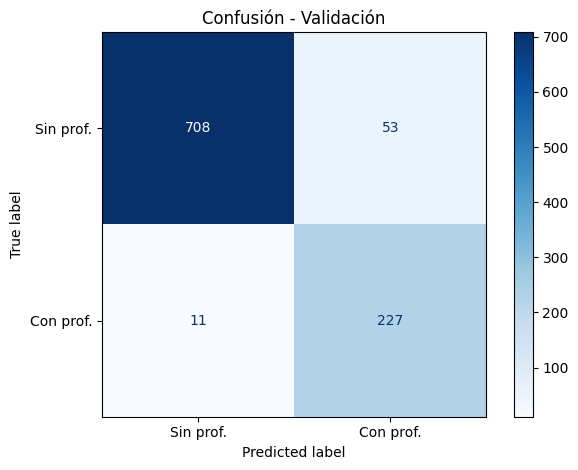

In [70]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluación general
eval_results = trainer.evaluate()
print("Resultados:")
for k, v in eval_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Detalle por clase
preds = trainer.predict(val_dataset)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = preds.label_ids

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=['Sin profesión','Con profesión']))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Sin prof.','Con prof.']).plot(cmap='Blues')
plt.title('Confusión - Validación')
plt.tight_layout(); plt.show()


## Genera predicciones

Genera predicciones sobre el test set. Recuerda que el archivo que generes y adjuntes al ejercicio debe tener dos columnas:


| id         | label |
|------------|-------|
| 1234567890 | 1     |
| 1234567891 | 0     |
| 1234567892 | 0     |
| 1234567893 | 1     |

- El archivo debe estar en formato **TSV** (separado por tabuladores).
- Debe contener exactamente **dos columnas**: `id` y `label`.
- Es obligatorio incluir la **cabecera**.


In [72]:
# Genero predicciones sobre el test set y no uso trainer.predict() porque las labels del test valen -1 y eso causa un error de CUDA.
# Así que hago inferencia directamente con el modelo.
import torch
from google.colab import files

model.eval()
predictions = []
test_texts = dataset_test_df['text'].tolist()
batch_size = 32

# Recorro el test en batches de 32 tweets
for i in range(0, len(test_texts), batch_size):
    batch = test_texts[i:i+batch_size]
    inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
    predictions.extend(preds)

# Creo el TSV con columnas 'id' y 'label' como pide el ejercicio
predictions_df = pd.DataFrame({'id': dataset_test_df['tweet_id'].values, 'label': predictions})

# Guardo el archivo (se almacena en /content/ en Colab)
output_file = 'MANRIQUE_LEZAMETA_STEPHANY_ejercicio1_predicciones.tsv'
predictions_df.to_csv(output_file, sep='\t', index=False)

print(f"Archivo guardado en: /content/{output_file}")
print(f"Total predicciones: {len(predictions_df)}")
print(predictions_df['label'].value_counts())
predictions_df.head()

# Descargo el archivo a mi PC automáticamente
files.download(output_file)


Archivo guardado en: /content/MANRIQUE_LEZAMETA_STEPHANY_ejercicio1_predicciones.tsv
Total predicciones: 1001
label
0    730
1    271
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Prueba de otros modelos